In [1]:
!pip install torch transformers datasets peft trl accelerate bitsandbytes swanlab

In [2]:
!pip install --upgrade torchao

In [3]:
!pip install "trl[vllm]>=0.25.0"

  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
Using cached transformers-4.57.6-py3-none-any.whl (12.0 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.13.0
    Uninstalling huggingface_hub-1.13.0:
      Successfully uninstalled huggingface_hub-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.7.0
    Uninstalling transformers-5.7.0:
      Successfully uninstalled transformers-5.7.0


In [4]:
!pip install transformers trl peft accelerate huggingface_hub tokenizers -U -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.18.0 requires transformers<5,>=4.56.0, but you have transformers 5.7.0 which is incompatible.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import sys
import importlib
import swanlab
from google.colab import userdata
import os


os.environ["SWANLAB_API_KEY"] = userdata.get('SWANLAB_API_KEY')
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

ROOT = "/content/drive/MyDrive/HPML Project"
sys.path.insert(0, f"{ROOT}/GRPO_profile")

In [7]:
# ── config ───────────────────────────────────────────────────────────────────
PROFILE_STEPS           = 20
PROFILE_START_STEP      = 0
PROFILE_LOG_DIR         = f"{ROOT}/GRPO_profile/log/profile_logs"

PROFILE_EVERY_N_STEPS   = 1
PRECISE_TIMING          = True

# ── settings ───────────────────────────────────────
TRAIN_BATCH_SIZE = 32
NUM_GENERATION = 16
GEN_BATCH_SIZE = 512

GRADIENT_CHECKPOINT = True
USE_VLLM = True
VLLM_MODE = "colocate"


EXPERIMENT_NAME = f"train_bs-{TRAIN_BATCH_SIZE}-gc-{GRADIENT_CHECKPOINT}-vllm-{USE_VLLM}"

CONFIG_FOLDER           = f"{ROOT}/GRPO_profile/{EXPERIMENT_NAME}"
CONFIG_PATH             = f"{CONFIG_FOLDER}/grpo_config.yaml"



# ── write config using those variables ───────────────────────────────────────
config_content = f"""
run:
  name: qwen25_3b_instruct_sft_grpo_g{NUM_GENERATION}_trainall
  output_root: RL_GRPO_train/outputs

model:
  base_model_name_or_path: Qwen/Qwen2.5-3B-Instruct
  adapter_path: /content/drive/MyDrive/HPML Project/benchmark/qwen25_3b_gsm8k_lora_sft_full
  tokenizer_name_or_path: /content/drive/MyDrive/HPML Project/benchmark/qwen25_3b_gsm8k_lora_sft_full
  trust_remote_code: true
  prompt_template: qwen_chat
  system_prompt: ""
  include_empty_system: false
  dtype: bf16
  device_map:
  load_in_4bit: false
  is_trainable_adapter: true

train_dataset:
  kind: sft_train
  name: openai/gsm8k
  config: main
  path: SFT/data/gsm8k_sft_train.json
  limit:

eval_dataset:
  kind: sft_val
  name: openai/gsm8k
  config: main
  path: SFT/data/gsm8k_sft_val.json
  limit: 725

final_eval_dataset:
  kind: gsm8k_test
  name: openai/gsm8k
  config: main
  start_index: 0
  limit:

reward:
  answer_correct: 1.0
  answer_incorrect: 0.0
  format_reward: 0.3
  parse_fail_penalty: -0.2
  length_penalty: -0.05
  min_completion_tokens: 20
  max_completion_tokens: 125

eval:
  every_steps: 10
  batch_size: 370
  max_prompt_length: 512
  max_new_tokens: 256
  metric_for_best: exact_match

grpo:
  per_device_train_batch_size: {TRAIN_BATCH_SIZE}
  num_generations: {NUM_GENERATION}
  generation_batch_size: {GEN_BATCH_SIZE}
  gradient_accumulation_steps: 1
  learning_rate: 1.0e-6
  max_prompt_length: 512
  max_completion_length: 128
  max_steps: 100
  warmup_ratio: 0.03
  weight_decay: 0.0
  max_grad_norm: 1.0
  beta: 0.001
  logging_steps: 3
  save_strategy: "no"
  eval_strategy: "no"
  remove_unused_columns: false
  gradient_checkpointing: {GRADIENT_CHECKPOINT}
  bf16: true
  report_to: "swanlab"
  run_name: qwen25_3b_instruct_sft_grpo_g{NUM_GENERATION}
  use_vllm: {USE_VLLM}
  vllm_mode: colocate
"""

os.makedirs(CONFIG_FOLDER, exist_ok=True)
with open(CONFIG_PATH, "w") as f:
    f.write(config_content.strip())

print(config_content)


run:
  name: qwen25_3b_instruct_sft_grpo_g16_trainall
  output_root: RL_GRPO_train/outputs

model:
  base_model_name_or_path: Qwen/Qwen2.5-3B-Instruct
  adapter_path: /content/drive/MyDrive/HPML Project/benchmark/qwen25_3b_gsm8k_lora_sft_full
  tokenizer_name_or_path: /content/drive/MyDrive/HPML Project/benchmark/qwen25_3b_gsm8k_lora_sft_full
  trust_remote_code: true
  prompt_template: qwen_chat
  system_prompt: ""
  include_empty_system: false
  dtype: bf16
  device_map:
  load_in_4bit: false
  is_trainable_adapter: true

train_dataset:
  kind: sft_train
  name: openai/gsm8k
  config: main
  path: SFT/data/gsm8k_sft_train.json
  limit:

eval_dataset:
  kind: sft_val
  name: openai/gsm8k
  config: main
  path: SFT/data/gsm8k_sft_val.json
  limit: 725

final_eval_dataset:
  kind: gsm8k_test
  name: openai/gsm8k
  config: main
  start_index: 0
  limit:

reward:
  answer_correct: 1.0
  answer_incorrect: 0.0
  format_reward: 0.3
  parse_fail_penalty: -0.2
  length_penalty: -0.05
  min_co

In [9]:
import sys
import io

# Fix for vLLM in Jupyter: restore real stdout fileno support
if not hasattr(sys.stdout, 'fileno') or callable(getattr(sys.stdout, 'fileno', None)):
    try:
        sys.stdout.fileno()
    except io.UnsupportedOperation:
        import os
        sys.stdout = open(os.devnull, 'w')  # or use sys.__stdout__

In [10]:
# ── clean slate (safe to re-run cell) ────────────────────────────────────────
for mod in list(sys.modules):
    if any(mod.startswith(m) for m in ["trl", "train_grpo", "profiled_trainer", "grpo_profiler"]):
        del sys.modules[mod]

# ── patch GRPOTrainer ─────────────────────────────────────────────────────────
import trl
from profiled_trainer import ProfiledGRPOTrainer

_orig_init = ProfiledGRPOTrainer.__init__
def _patched_init(self, *args, **kwargs):
    kwargs.setdefault("profile_steps",          PROFILE_STEPS)
    kwargs.setdefault("profile_start_step",     PROFILE_START_STEP)
    kwargs.setdefault("profile_log_dir",        PROFILE_LOG_DIR)
    kwargs.setdefault("profile_every_n_steps",  PROFILE_EVERY_N_STEPS)
    kwargs.setdefault("precise_timing",         PRECISE_TIMING)
    _orig_init(self, *args, **kwargs)
ProfiledGRPOTrainer.__init__ = _patched_init

trl.GRPOTrainer = ProfiledGRPOTrainer
importlib.import_module("trl.trainer.grpo_trainer").GRPOTrainer = ProfiledGRPOTrainer

# ── patch load_config to inject max_steps at runtime ─────────────────────────
import train_grpo

MAX_STEPS = PROFILE_START_STEP + PROFILE_STEPS

_orig_load_config = train_grpo.load_config
def _patched_load_config(path):
    cfg = _orig_load_config(path)
    cfg.setdefault("grpo", {})["max_steps"]   = MAX_STEPS
    cfg.setdefault("eval", {})["every_steps"] = MAX_STEPS + 1
    return cfg
train_grpo.load_config = _patched_load_config

# ── init swanlab ──────────────────────────────────────────────────────────────
import swanlab
swanlab.init(
    project="grpo-profiling",
    experiment_name=EXPERIMENT_NAME,
    config={
        "profile_steps":         PROFILE_STEPS,
        "profile_start_step":    PROFILE_START_STEP,
        "profile_every_n_steps": PROFILE_EVERY_N_STEPS,
        "precise_timing":        PRECISE_TIMING,
        "max_steps":             MAX_STEPS,
        "config_path":           CONFIG_PATH,
    },
)

# ── run ───────────────────────────────────────────────────────────────────────
sys.argv = ["train_grpo.py", "--config", CONFIG_PATH]
train_grpo.main()

swanlab.finish()

swanlab: You have already initialized a run, the init function will be ignored

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:02<00:00, 17.48it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 51/51 [00:02<00:00, 19.41it/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
3,-0.002436
6,0.002055
9,0.003346
12,0.000125
15,0.001690
18,-0.002062


Greedy eval step 20:   0%|          | 0/1 [00:00<?, ?it/s]

swanlab: 🏠 View project at https://swanlab.cn/@lsy_8117/grpo-profiling

swanlab: 🚀 View run at https://swanlab.cn/@lsy_8117/grpo-profiling/runs/n92i6ykecg2dbd75gaeh7

In [ ]:
swanlab.finish()

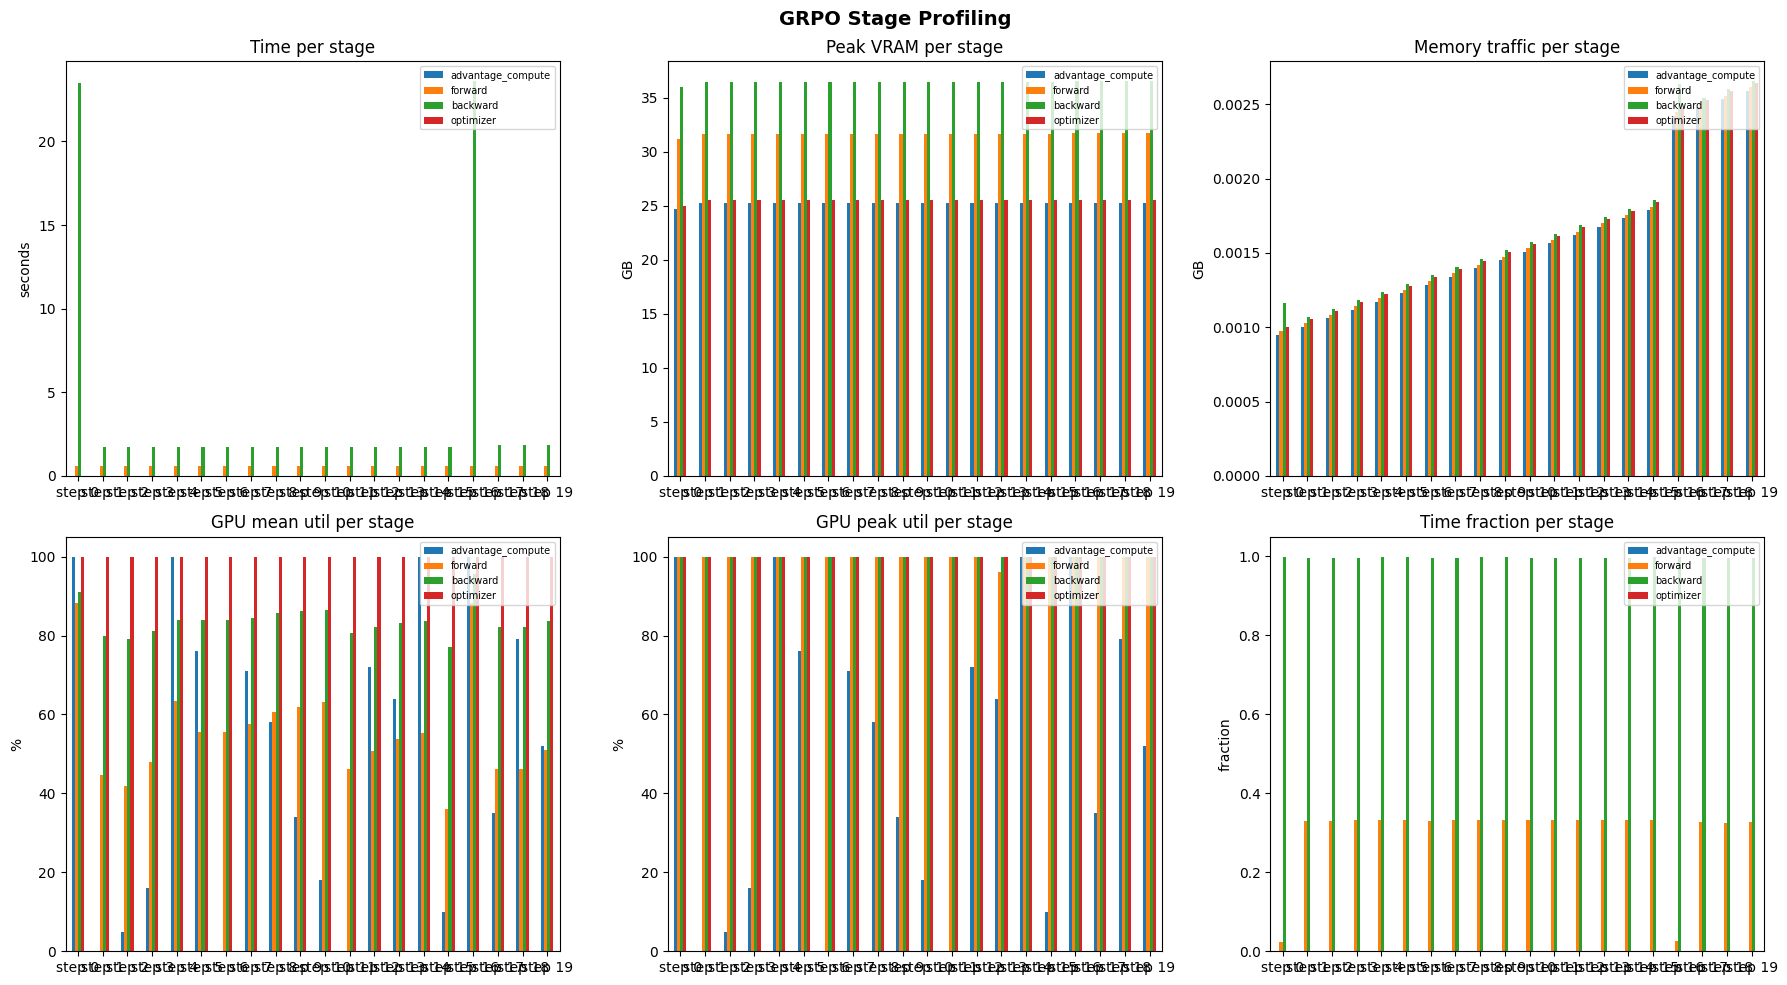

In [11]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

records = []
for f in sorted(glob.glob(f"{PROFILE_LOG_DIR}/step_*.json")):
    with open(f) as fh:
        records.append(json.load(fh))

df = pd.DataFrame(records)
steps = [str(int(r.get("profile/global_step", i))) for i, r in enumerate(records)]
stages = ["rollout", "reward_compute", "advantage_compute", "forward", "backward", "optimizer"]

def plot_metric(ax, metric_prefix, title, ylabel):
    cols = [f"{metric_prefix}/{s}" for s in stages if f"{metric_prefix}/{s}" in df.columns]
    if not cols:
        ax.set_visible(False)
        return
    data = df[cols].copy()
    data.index = [f"step {s}" for s in steps]
    data.columns = [c.split("/")[1] for c in cols]
    data.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(data.index, rotation=0)
    ax.legend(loc="upper right", fontsize=7)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_metric(axes[0, 0], "time",           "Time per stage",           "seconds")
plot_metric(axes[0, 1], "peak_vram",      "Peak VRAM per stage",      "GB")
plot_metric(axes[0, 2], "memory_traffic", "Memory traffic per stage", "GB")
plot_metric(axes[1, 0], "gpu_util_mean",  "GPU mean util per stage",  "%")
plot_metric(axes[1, 1], "gpu_util_peak",  "GPU peak util per stage",  "%")
plot_metric(axes[1, 2], "time_frac",      "Time fraction per stage",  "fraction")

plt.suptitle("GRPO Stage Profiling", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROFILE_LOG_DIR}/profile_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {PROFILE_LOG_DIR}/profile_results.png")

## Version fix

In [ ]:
# import json

# path = f"{ROOT}/benchmark/qwen25_3b_gsm8k_lora_sft_full/tokenizer_config.json"  # update this to your actual path

# with open(path) as f:
#     cfg = json.load(f)

# tokens = cfg.get("extra_special_tokens", [])
# if isinstance(tokens, list):
#     cfg["extra_special_tokens"] = {t: t for t in tokens}
#     with open(path, "w") as f:
#         json.dump(cfg, f, indent=2)
#     print("Fixed!")
# else:
#     print("Already a dict, no change needed.")